# Implied Volatility

## Definition

Implied volatility (IV) is the volatility parameter that, when inserted into an option pricing model, reproduces the observed market price of an option. Formally, it is defined as the value of the volatility parameter \( \sigma \) that solves the equation:

\[
C_{mkt} = C_{model}(S_0, K, T, r, q, \sigma)
\]

where:

- \(C_{mkt}\) is the observed market price of the option  
- \(C_{model}\) is the theoretical price given by an option pricing model  
- \(S_0\) is the current price of the underlying asset  
- \(K\) is the strike price  
- \(T\) is the time to maturity  
- \(r\) is the risk-free interest rate  
- \(q\) is the dividend yield  
- \( \sigma \) is the volatility parameter  

Implied volatility is therefore **not directly observable**. It must be obtained numerically by inverting an option pricing model.

---

## Implied Volatility under the Black–Scholes Model

Under the Black–Scholes framework, the price of a European call option is given by

\[
C = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2)
\]

with

\[
d_1 = \frac{\ln(S_0/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma \sqrt{T}}
\]

\[
d_2 = d_1 - \sigma \sqrt{T}
\]

where \(N(\cdot)\) denotes the cumulative distribution function of the standard normal distribution.

Since the option price is monotonic in volatility, the implied volatility can be obtained by solving:

\[
C_{BS}(\sigma) - C_{mkt} = 0
\]

using numerical root-finding methods such as:

- Newton–Raphson
- Bisection method
- Brent’s method

---

## Economic Interpretation

Implied volatility represents the **market’s consensus estimate of future volatility** of the underlying asset over the life of the option. However, it should not be interpreted as a pure forecast of realized volatility.

Instead, implied volatility reflects:

- expected future uncertainty
- supply and demand for options
- risk premia embedded in option prices

As a result, implied volatility is often considered a **risk-neutral expectation of volatility**.

---

## Volatility Smile and Volatility Surface

In the Black–Scholes model, volatility is assumed to be constant across strikes and maturities. Empirically, however, implied volatility varies systematically with both.

### Volatility Smile

For a fixed maturity, implied volatility typically varies across strikes, producing a **volatility smile** or **skew**.

This phenomenon reflects market features such as:

- asymmetric risk perceptions
- crash risk in equity markets
- supply/demand imbalances for options

---

### Volatility Surface

The collection of implied volatilities across strikes and maturities defines the **volatility surface**:

\[
\sigma = \sigma(K,T)
\]

A volatility surface is typically represented as a two-dimensional grid where:

- the **strike dimension** captures the smile or skew  
- the **maturity dimension** captures the term structure of volatility  

Interpolation across this surface is required to obtain implied volatilities for arbitrary combinations of strike and maturity.

A common practice is to interpolate **total variance** rather than volatility:

\[
w(K,T) = \sigma^2(K,T) T
\]

This approach improves numerical stability and helps maintain no-arbitrage conditions across maturities.

---

## Forward Moneyness Representation

In many applications, particularly for index or futures options, the volatility surface is parameterized using **log-moneyness relative to the forward price**:

\[
k = \ln\left(\frac{K}{F(T)}\right)
\]

where \(F(T)\) is the forward price of the underlying asset.

This representation improves stability across maturities because it normalizes the strike relative to the forward level.

---

## Practical Importance

Implied volatility plays a central role in financial markets and is used for:

- option pricing and hedging
- volatility trading strategies
- calibration of stochastic volatility models
- construction of volatility indices (e.g. VIX)

Traders often quote option prices directly in terms of implied volatility rather than monetary price.

---

## Numerical Computation

Because implied volatility requires solving a nonlinear equation, numerical methods are required. One commonly used approach is the Newton–Raphson method:

\[
\sigma_{n+1} = \sigma_n - \frac{C(\sigma_n) - C_{mkt}}{Vega(\sigma_n)}
\]

where the **vega** of the option is

\[
Vega = \frac{\partial C}{\partial \sigma} = S_0 e^{-qT} \sqrt{T} \, \phi(d_1)
\]

and \( \phi(\cdot) \) is the standard normal density.

---

## References

Black, F., & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3), 637–654.

Black, F. (1976). *The Pricing of Commodity Contracts*. Journal of Financial Economics, 3(1–2), 167–179.

Hull, J. C. (2018). *Options, Futures, and Other Derivatives*. Pearson.

Gatheral, J. (2006). *The Volatility Surface: A Practitioner’s Guide*. Wiley.

Wilmott, P. (2006). *Paul Wilmott on Quantitative Finance*. Wiley.

In [14]:
import numpy as np
from scipy.stats import norm


def vola_implicita(T, K, r, S0, sig0, N_max, toll, C_mkt):

    d1 = np.zeros(N_max)
    d2 = np.zeros(N_max)
    Dd1 = np.zeros(N_max)
    Dd2 = np.zeros(N_max)
    f = np.zeros(N_max)
    Df = np.zeros(N_max)

    V = np.zeros(N_max)
    V[0] = sig0

    # primo step
    d1[0] = (np.log(S0/K) + (r + 0.5*(V[0])**2)*T) / (V[0]*np.sqrt(T))
    d2[0] = d1[0] - V[0]*np.sqrt(T)

    Dd1[0] = np.sqrt(T) - (np.log(S0/K) + (r + 0.5*(V[0])**2)*T) / ((V[0]**2)*np.sqrt(T))
    Dd2[0] = Dd1[0] - np.sqrt(T)

    f[0] = S0*norm.cdf(d1[0]) - K*np.exp(-r*T)*norm.cdf(d2[0]) - C_mkt

    Df[0] = S0*norm.pdf(d1[0])*Dd1[0] - K*np.exp(-r*T)*norm.pdf(d2[0])*Dd2[0]

    V[1] = V[0] - f[0]/Df[0]

    i = 1

    while abs(V[i] - V[i-1]) > toll and i < N_max-1:

        d1[i] = (np.log(S0/K) + (r + 0.5*(V[i])**2)*T) / (V[i]*np.sqrt(T))
        d2[i] = d1[i] - V[i]*np.sqrt(T)

        Dd1[i] = np.sqrt(T) - (np.log(S0/K) + (r + 0.5*(V[i])**2)*T) / ((V[i]**2)*np.sqrt(T))
        Dd2[i] = Dd1[i] - np.sqrt(T)

        f[i] = S0*norm.cdf(d1[i]) - K*np.exp(-r*T)*norm.cdf(d2[i]) - C_mkt

        Df[i] = S0*norm.pdf(d1[i])*Dd1[i] - K*np.exp(-r*T)*norm.pdf(d2[i])*Dd2[i]

        V[i+1] = V[i] - f[i]/Df[i]

        i += 1

    # equivalente di find(V)
    ind = np.nonzero(V)[0]

    IV = V[ind[-1]]

    return IV

In [15]:
T = 1
K = 100
r = 0.02
S0 = 100
sig0 = 0.2
N_max = 100
toll = 1e-6
C_mkt = 10

iv = vola_implicita(T, K, r, S0, sig0, N_max, toll, C_mkt)

print("Volatilità implicita:", iv)

Volatilità implicita: 0.22772303157063306


In [16]:
import numpy as np
import matplotlib.pyplot as plt


def plot_vol_surface(strikes, maturities, vol_surface, title="Volatility Surface"):
    """
    Plotta la superficie di volatilità implicita.

    Parametri
    ---------
    strikes : array-like
        Vettore degli strike, lunghezza n_strikes
    maturities : array-like
        Vettore delle scadenze, lunghezza n_maturities
    vol_surface : 2D array-like
        Matrice delle volatilità implicite di dimensione
        (n_maturities, n_strikes)
    title : str
        Titolo del grafico
    """
    strikes = np.array(strikes)
    maturities = np.array(maturities)
    vol_surface = np.array(vol_surface)

    X, Y = np.meshgrid(strikes, maturities)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(X, Y, vol_surface, cmap='viridis', edgecolor='k', alpha=0.9)

    ax.set_xlabel("Strike")
    ax.set_ylabel("Maturity")
    ax.set_zlabel("Implied Volatility")
    ax.set_title(title)

    fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, label="Volatility")

    plt.tight_layout()
    plt.show()

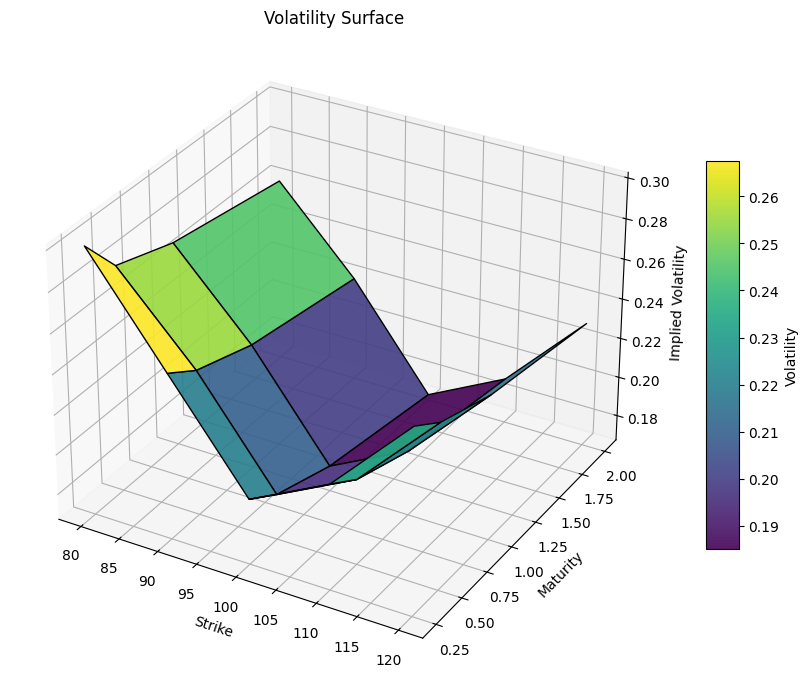

In [17]:
strikes = [80, 90, 100, 110, 120]
maturities = [0.25, 0.5, 1.0, 2.0]

vol_surface = [
    [0.30, 0.25, 0.20, 0.22, 0.26],
    [0.28, 0.24, 0.19, 0.21, 0.25],
    [0.27, 0.23, 0.18, 0.20, 0.24],
    [0.26, 0.22, 0.17, 0.19, 0.23]
]

plot_vol_surface(strikes, maturities, vol_surface)

In [18]:
import numpy as np
from scipy.interpolate import interp1d


def implied_vol_from_surface(strikes, maturities, vol_surface, K_target, T_target):

    strikes = np.array(strikes, dtype=float)
    maturities = np.array(maturities, dtype=float)
    vol_surface = np.array(vol_surface, dtype=float)

    # Controlli base
    if vol_surface.shape != (len(maturities), len(strikes)):
        raise ValueError("La dimensione di vol_surface deve essere (len(maturities), len(strikes))")

    if T_target <= 0:
        raise ValueError("T_target deve essere > 0")

    # Se la maturity è già presente, interpolo solo sullo strike
    if T_target in maturities:
        idx = np.where(maturities == T_target)[0][0]
        vol_interp_strike = interp1d(
            strikes,
            vol_surface[idx, :],
            kind='linear',
            fill_value='extrapolate'
        )
        return float(vol_interp_strike(K_target))

    # Trovo le due maturities che racchiudono T_target
    if T_target < maturities[0] or T_target > maturities[-1]:
        raise ValueError("T_target fuori dal range delle maturities")

    idx_upper = np.searchsorted(maturities, T_target)
    idx_lower = idx_upper - 1

    T1 = maturities[idx_lower]
    T2 = maturities[idx_upper]

    # Interpolazione della vol sui due smile alle due maturities
    vol_interp_T1 = interp1d(
        strikes,
        vol_surface[idx_lower, :],
        kind='linear',
        fill_value='extrapolate'
    )
    vol_interp_T2 = interp1d(
        strikes,
        vol_surface[idx_upper, :],
        kind='linear',
        fill_value='extrapolate'
    )

    sigma1 = float(vol_interp_T1(K_target))
    sigma2 = float(vol_interp_T2(K_target))

    # Interpolazione sulla total variance
    w1 = sigma1**2 * T1
    w2 = sigma2**2 * T2

    w_target = w1 + (T_target - T1) * (w2 - w1) / (T2 - T1)

    sigma_target = np.sqrt(w_target / T_target)

    return float(sigma_target)

In [19]:
strikes = [80, 90, 100, 110, 120]
maturities = [0.25, 0.5, 1.0, 2.0]

vol_surface = [
    [0.30, 0.26, 0.22, 0.24, 0.28],
    [0.29, 0.25, 0.21, 0.23, 0.27],
    [0.27, 0.23, 0.20, 0.22, 0.25],
    [0.26, 0.22, 0.19, 0.21, 0.24]
]

K_target = 105
T_target = 0.75

iv = implied_vol_from_surface(strikes, maturities, vol_surface, K_target, T_target)
print("Volatilità implicita interpolata:", iv)

Volatilità implicita interpolata: 0.21338541031038963
